In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

# Data Cleaning

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

# EDA (Exploratory Data Analysis)

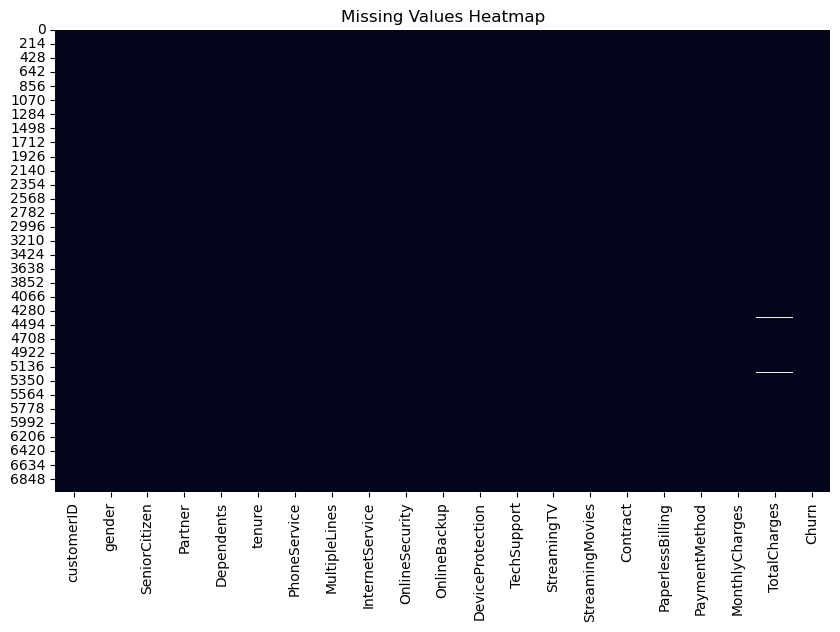

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

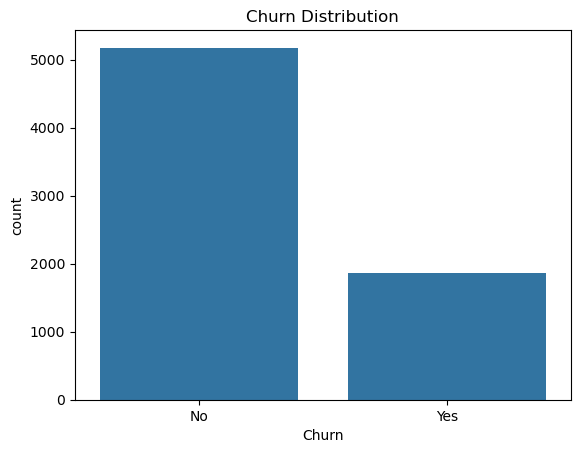

In [11]:
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution")
plt.show()

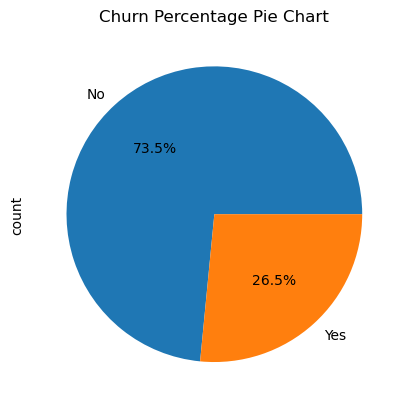

In [12]:
df["Churn"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Churn Percentage Pie Chart")
plt.show()

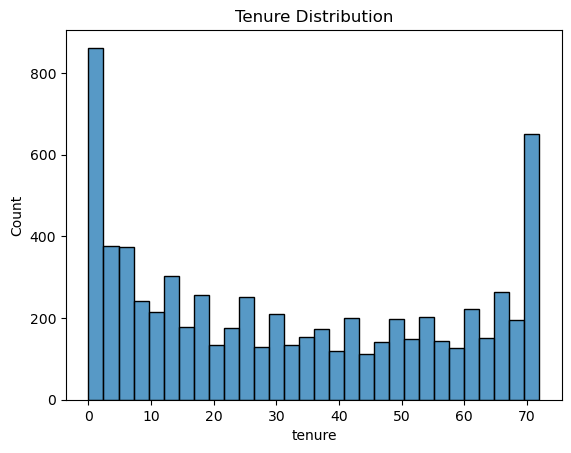

In [13]:
sns.histplot(df["tenure"],bins=30)
plt.title("Tenure Distribution")
plt.show()

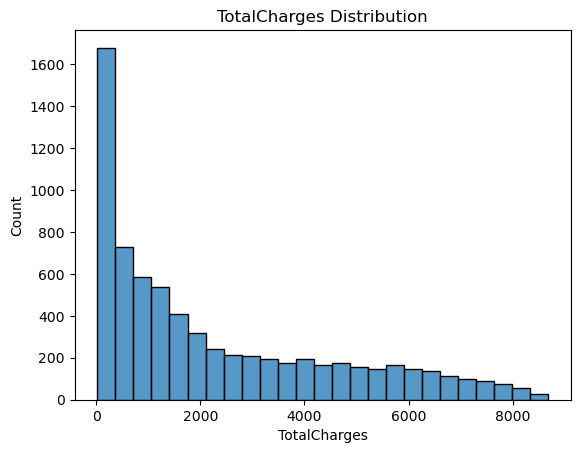

In [14]:
sns.histplot(df["TotalCharges"])
plt.title("TotalCharges Distribution")
plt.show()

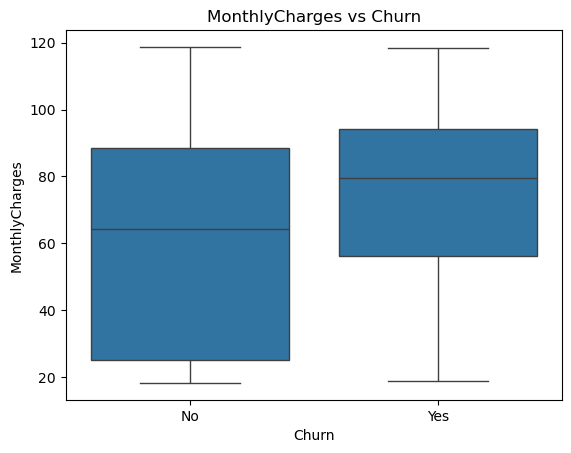

In [15]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("MonthlyCharges vs Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

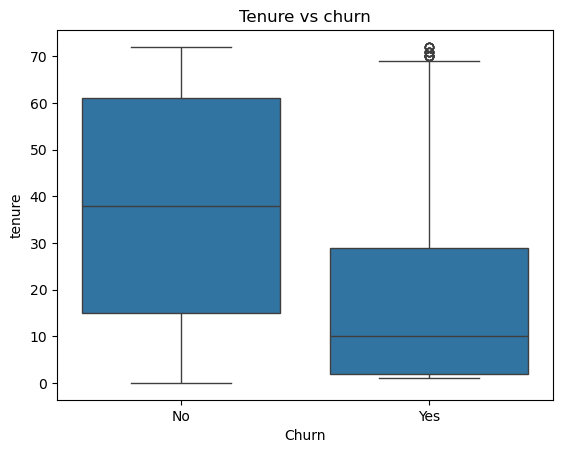

In [16]:
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs churn")
plt.show()

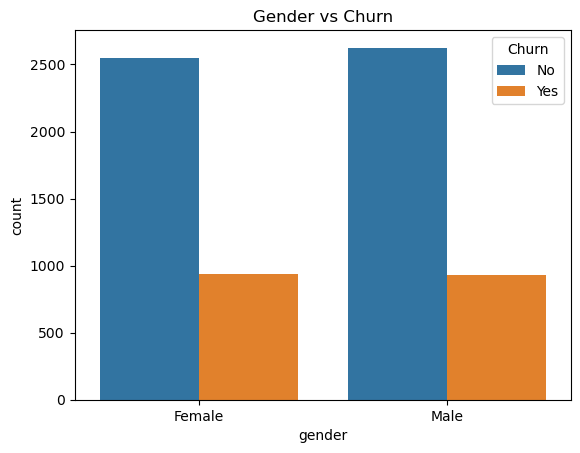

In [17]:
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Gender vs Churn")
plt.show()

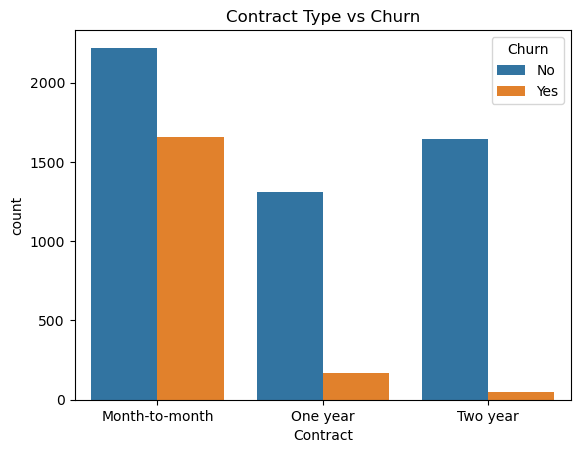

In [18]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Contract Type vs Churn")
plt.show()

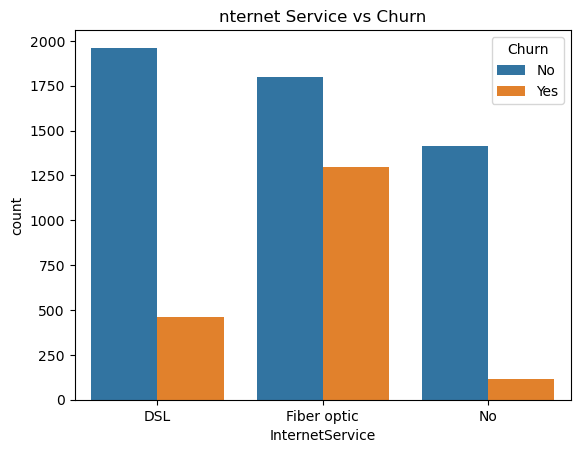

In [19]:
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.title("nternet Service vs Churn")
plt.show()

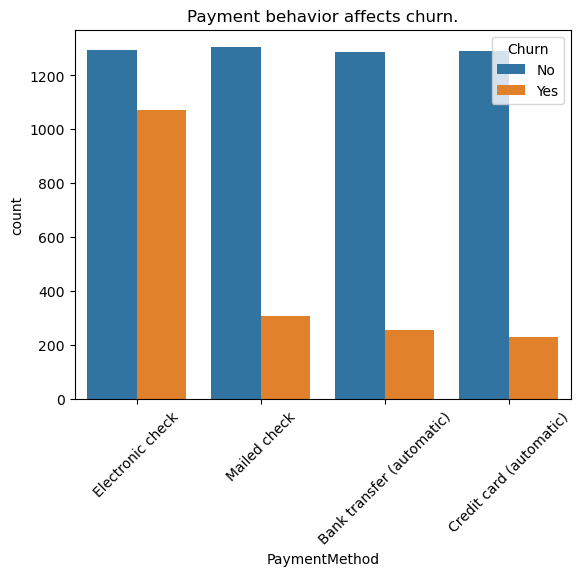

In [20]:
sns.countplot(x="PaymentMethod",hue="Churn",data=df)
plt.title("Payment behavior affects churn.")
plt.xticks(rotation=45)
plt.show()

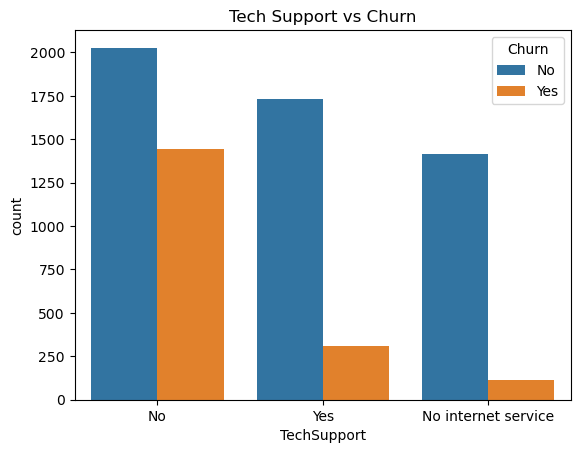

In [21]:
sns.countplot(x="TechSupport",hue="Churn",data=df)
plt.title("Tech Support vs Churn")
plt.show()

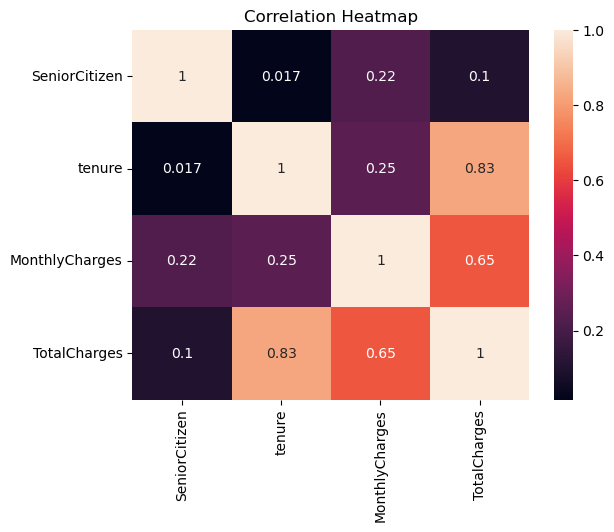

In [22]:
num=df.select_dtypes(include="number")
sns.heatmap(num.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

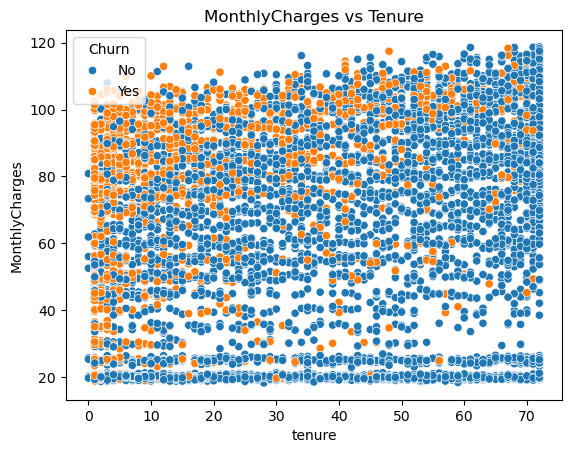

In [23]:
sns.scatterplot(
x="tenure",
y="MonthlyCharges",
hue="Churn",
data=df
)
plt.title("MonthlyCharges vs Tenure")
plt.show()

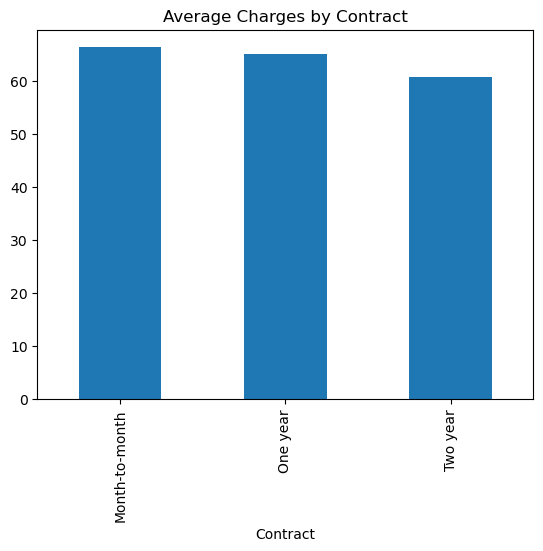

In [24]:
df.groupby("Contract")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Average Charges by Contract")
plt.show()

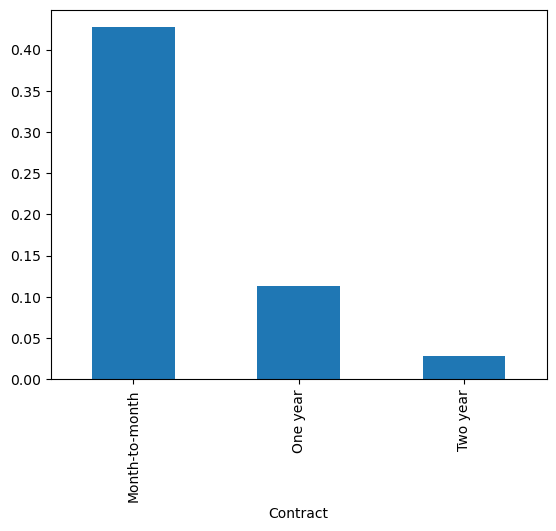

In [25]:
(df.groupby("Contract")["Churn"].value_counts(normalize=True)
.unstack()["Yes"]).plot(kind="bar")
plt.title("")
plt.show()

In [56]:
df.to_csv("telco_cleaned.csv", index=False)